TABELA WYNIKÓW — LICZBA REYNOLDSA I KLASYFIKACJA PRZEPŁYWU (3 KLASY)
 P_przed    P_za  delta_p      Q        Re       Regime
 22.3000 18.9000   3.4000 0.0000  908.7959      laminar
 22.7000 18.4000   4.3000 0.0000 1099.9516      laminar
 23.4000 17.4000   6.0000 0.0000 1372.6371      laminar
 24.6000 15.8000   8.8000 0.0000 1800.6578      laminar
 25.0000 15.4000   9.6000 0.0000 2020.0370 transitional
 25.5000 14.8000  10.7000 0.0000 2061.2475 transitional
 26.1000 14.0000  12.1000 0.0000 2139.7215 transitional
 26.5000 13.5000  13.0000 0.0000 2176.4757 transitional
 27.0000 13.1000  13.9000 0.0000 2524.0276 transitional
 27.6000 12.0000  15.6000 0.0000 2446.1903 transitional
 28.0000 11.8000  16.2000 0.0000 2561.3336 transitional
 28.5000 11.2000  17.3000 0.0000 2656.7416 transitional
 21.4000 19.9000   1.5000 0.0000  471.4806      laminar
 21.8000 19.4000   2.4000 0.0000  639.4633      laminar
 22.4000 18.8000   3.6000 0.0000  860.3704      laminar
 22.8000 18.3000   4.5000 0.0000 11

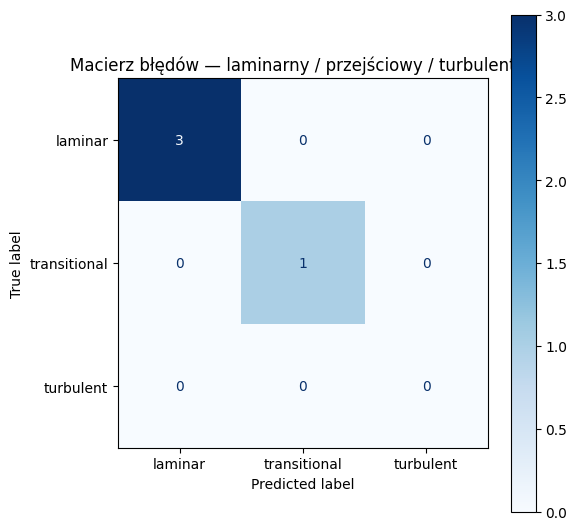

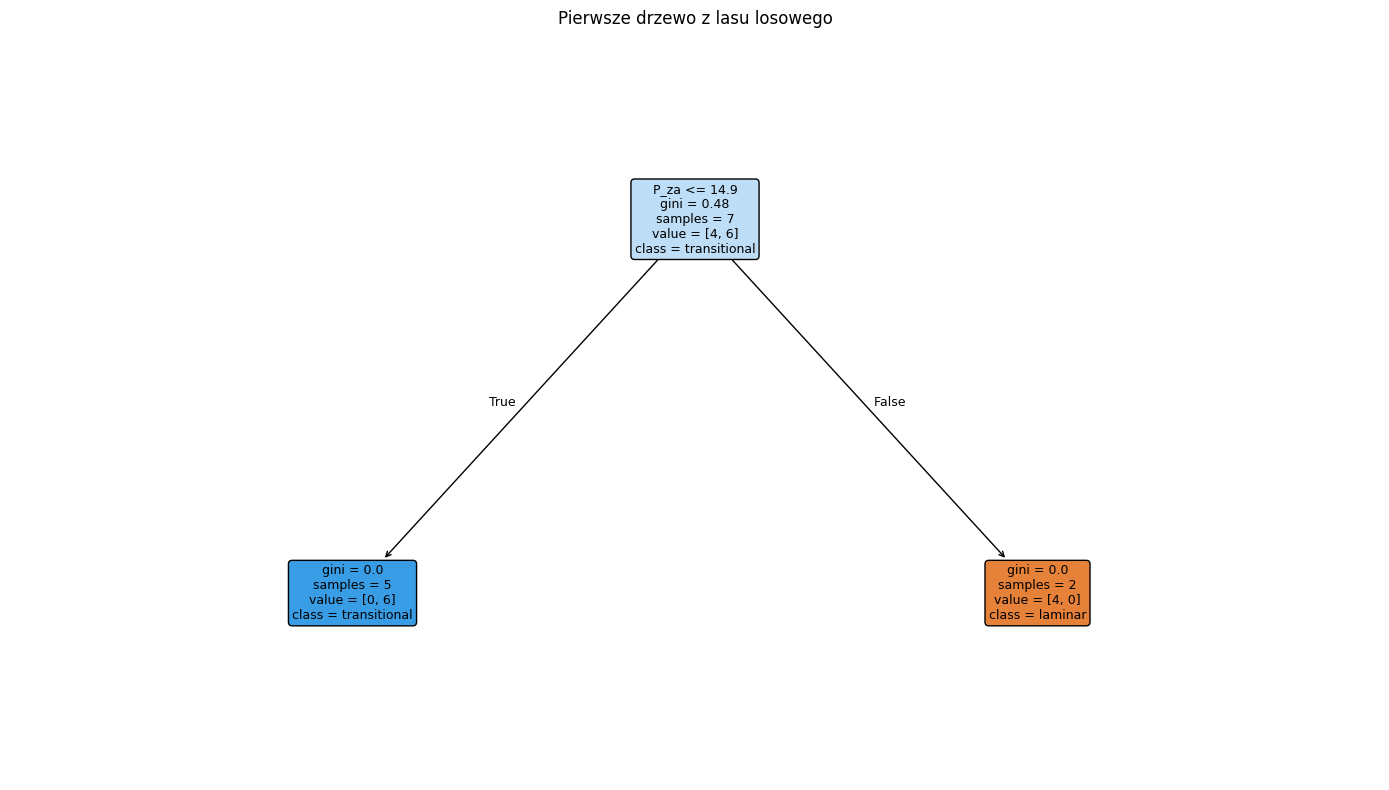

Ważność cech (permutation importance, odpowiednik OOB):
  P_przed: 0.4528
  P_za: 0.0889



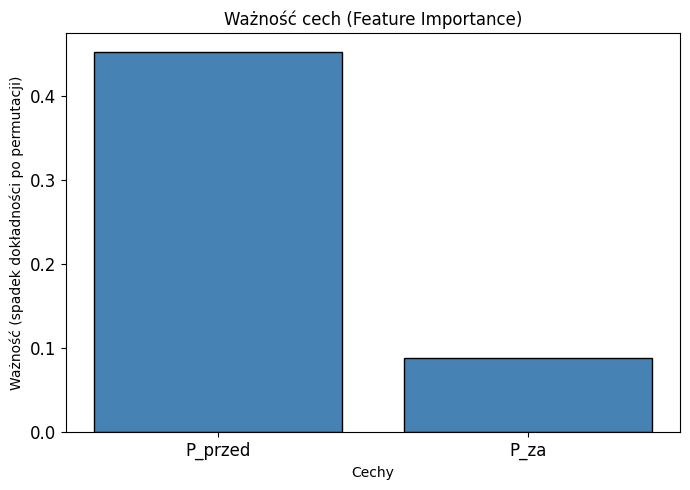

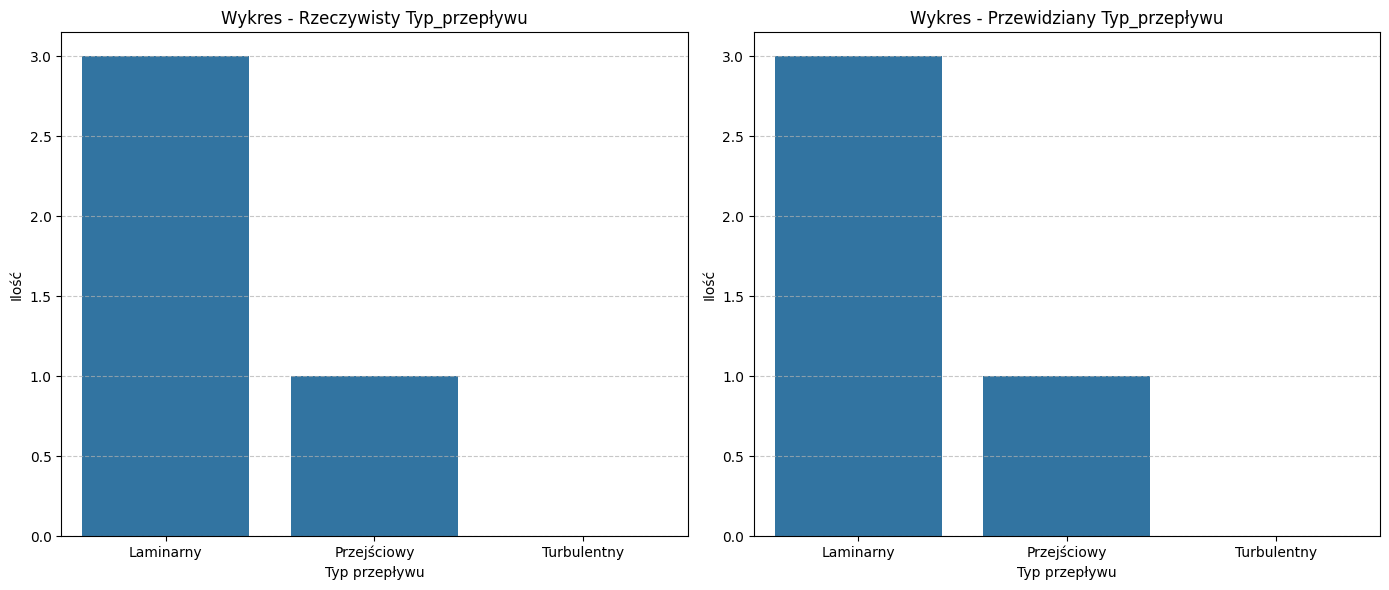

Rzeczywisty:
Typ_przepływu
Laminarny      3
Przejściowy    1
Name: count, dtype: int64

Przewidziany:
Typ_przepływu
Laminarny      3
Przejściowy    1
Name: count, dtype: int64

Zapisane wykresy: confusion_matrix.png, first_tree.png, feature_importance.png, rozklad_klas_rzeczywisty_vs_przewidziany.png


In [ ]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.inspection import permutation_importance
from sklearn.tree import plot_tree

# Dane pomiarowe

data = {
    "P_przed": [22.3, 22.7, 23.4, 24.6, 25.0, 25.5, 26.1, 26.5,
                27.0, 27.6, 28.0, 28.5, 21.4, 21.8, 22.4, 22.8],
    "P_za":    [18.9, 18.4, 17.4, 15.8, 15.4, 14.8, 14.0, 13.5,
                13.1, 12.0, 11.8, 11.2, 19.9, 19.4, 18.8, 18.3],
    "delta_p": [3.4, 4.3, 6.0, 8.8, 9.6, 10.7, 12.1, 13.0,
                13.9, 15.6, 16.2, 17.3, 1.5, 2.4, 3.6, 4.5],
    "Q": [2.1413e-06, 2.5917e-06, 3.2342e-06, 4.2427e-06, 4.7596e-06, 4.8567e-06,
          5.0416e-06, 5.1282e-06, 5.9471e-06, 5.7637e-06, 6.0350e-06, 6.2598e-06,
          1.1109e-06, 1.5067e-06, 2.0272e-06, 2.7439e-06],
}
df = pd.DataFrame(data)

# Obliczenie liczby Reynoldsa (Re)

D = 0.003     # średnica przewodu [m]
nu = 1e-6     # lepkość kinematyczna wody [m2/s]

df["Re"] = 4 * df["Q"] / (np.pi * D * nu)

# Kryterium:
#   Re < 2000             -> laminarny
#   2000 <= Re < 3000      -> przejściowy
#   Re >= 3000             -> turbulentny
#
# Mapowanie liczbowe:
#   0 -> laminar (laminarny)
#   1 -> transitional (przejściowy)
#   2 -> turbulent (turbulentny)

conditions = [
    df["Re"] < 2000,
    (df["Re"] >= 2000) & (df["Re"] < 3000),
    df["Re"] >= 3000,
]
choices = ["laminar", "transitional", "turbulent"]
df["Regime"] = np.select(conditions, choices, default="turbulent")

print("=" * 78)
print("TABELA WYNIKÓW — LICZBA REYNOLDSA I KLASYFIKACJA PRZEPŁYWU (3 KLASY)")
print("=" * 78)
print(df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print()
print("Liczba próbek w każdej klasie:")
print(df["Regime"].value_counts().to_string())
print()


# Klasyfikacja RandomForest
# x - ciśnienia przed i za
# y - laminar/turbulent/transitional

X = df[["P_przed", "P_za"]].values   # kształt (16, 2)
y = df["Regime"].values              # kształt (16,)

print(f"Wymiary X (cechy):   {X.shape}")
print(f"Wymiary y (etykiety): {y.shape}")
print()


# Podzial danych na zbiór treningowy i testowy (80%/20%)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,      # 20% danych do testu
    random_state=42,     # ustalony seed
)

print(f"Liczba próbek treningowych: {len(X_train)}")
print(f"Liczba próbek testowych:    {len(X_test)}")
print()


# Las losowy - odpowiednik TreeBagger w MATLAB-ie

rf_model = RandomForestClassifier(
    n_estimators=300,
    bootstrap=True,
    min_samples_leaf=1,
    max_leaf_nodes=10,
    max_samples=0.8,
    oob_score=True,
    random_state=42,
)

rf_model.fit(X_train, y_train)

print(f"Wynik OOB (Out-Of-Bag) na zbiorze treningowym: {rf_model.oob_score_:.4f}")
print(f"Klasy rozpoznane przez model: {list(rf_model.classes_)}")
print()


# Predykcja i ocena dokładności

predicted_labels = rf_model.predict(X_test)
scores = rf_model.predict_proba(X_test)

accuracy = accuracy_score(y_test, predicted_labels)

print("Porównanie predykcji z rzeczywistymi etykietami (zbiór testowy):")
for true_label, pred_label in zip(y_test, predicted_labels):
    znacznik = "OK" if true_label == pred_label else "BŁĄD"
    print(f"  rzeczywisty: {true_label:<13}  przewidziany: {pred_label:<13}  [{znacznik}]")
print()
print(f"Dokładność (Accuracy): {accuracy * 100:.2f}%")
print()


# Macierz błędów (Confusion Matrix) — odpowiednik confusionmat w MATLAB-ie

labels_order = ["laminar", "transitional", "turbulent"]
conf_mat = confusion_matrix(y_test, predicted_labels, labels=labels_order)

fig1, ax1 = plt.subplots(figsize=(6, 5.5))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_mat, display_labels=labels_order)
disp.plot(ax=ax1, cmap="Blues", colorbar=True, values_format="d")
ax1.set_title("Macierz błędów — laminarny / przejściowy / turbulentny")
plt.tight_layout()
plt.show()


# Wizualizacja pierwszego drzewa z lasu losowego

fig2, ax2 = plt.subplots(figsize=(14, 8))
plot_tree(
    rf_model.estimators_[0],
    feature_names=["P_przed", "P_za"],
    class_names=rf_model.classes_,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax2,
)
ax2.set_title("Pierwsze drzewo z lasu losowego")
plt.tight_layout()
plt.show()


# Ważność cech (Feature Importance) — odpowiednik OOBPermutedVarDeltaError w MATLAB-ie
# OOBPermutedVarDeltaError w MATLAB-ie mierzy, jak bardzo wzrasta błąd
# predykcji Out-Of-Bag po losowej permutacji wartości danej cechy.
# permutation_importance() w scikit-learn realizuje tę samą ideę: permutuje
# po kolei każdą cechę i mierzy spadek jakości modelu (tutaj: accuracy).
# Działa identycznie dla klasyfikacji wieloklasowej.

perm_result = permutation_importance(
    rf_model, X_train, y_train,
    n_repeats=30,         # liczba powtórzeń permutacji dla stabilności wyniku
    random_state=42,
    scoring="accuracy",
)
feature_importance = perm_result.importances_mean
feature_names = ["P_przed", "P_za"]

print("Ważność cech:")
for name, imp in zip(feature_names, feature_importance):
    print(f"  {name}: {imp:.4f}")
print()

fig3, ax3 = plt.subplots(figsize=(7, 5))
ax3.bar(feature_names, feature_importance, color="steelblue", edgecolor="black")
ax3.set_xlabel("Cechy")
ax3.set_ylabel("Ważność (spadek dokładności po permutacji)")
ax3.tick_params(axis="both", labelsize=12)
plt.tight_layout()
plt.show()


# Porównanie rozkładu klas rzeczywistych i przewidzianych (laminar / transitional / turbulent)

flow_type_labels_pl = {
    "laminar": "Laminarny",
    "transitional": "Przejściowy",
    "turbulent": "Turbulentny",
}

y_true_labels = pd.Series(y_test, name="Typ_przepływu").map(flow_type_labels_pl)
y_pred_labels = pd.Series(predicted_labels, name="Typ_przepływu").map(flow_type_labels_pl)

# Ustalona kolejność kategorii na osi X (żeby obie strony wykresu były porównywalne)
order_pl = ["Laminarny", "Przejściowy", "Turbulentny"]

fig4, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.countplot(x=y_true_labels, order=order_pl, ax=axes[0])
axes[0].set_title("Wykres - Rzeczywisty Typ_przepływu")
axes[0].set_xlabel("Typ przepływu")
axes[0].set_ylabel("Ilość")
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

sns.countplot(x=y_pred_labels, order=order_pl, ax=axes[1])
axes[1].set_title("Wykres - Przewidziany Typ_przepływu")
axes[1].set_xlabel("Typ przepływu")
axes[1].set_ylabel("Ilość")
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

print("Rzeczywisty:")
print(y_true_labels.value_counts())

print("\nPrzewidziany:")
print(y_pred_labels.value_counts())
print()

print("Zapisane wykresy: confusion_matrix.png, first_tree.png, feature_importance.png, "
      "rozklad_klas_rzeczywisty_vs_przewidziany.png")